# Data Scientist Practical Exam — **Final Submission (v5.1)**

*Generated: 2025-11-06 12:02*

**This version improves raw accuracy over v4/v5** via richer features, accuracy-first threshold sweeps,
soft-voting ensemble with weight search, and a clear final report (Accuracy, F1, AUC, PR/ROC, Precision@K).

**Contents**
1. Data Validation & Cleaning  
2. Exploratory Analysis (2 univariate + 1 multivariate) + findings  
3. Feature Engineering (v5.1)  
4. Model Development (strong single models)  
5. Accuracy-First Optimization (threshold sweep)  
6. Ensemble (weight search)  
7. Final Evaluation & Business Metrics  
8. Final Summary & Recommendations


In [1]:

# === Environment Check ===
import sys, subprocess
for p in ["numpy","pandas","matplotlib","seaborn","scikit-learn","xgboost","scipy"]:
    try:
        __import__(p); print(f"✅ {p} available")
    except ImportError:
        print(f"📦 Installing {p} ...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", p, "--quiet"])
            __import__(p); print(f"✅ {p} installed")
        except Exception as e:
            print(f"⚠️ Could not install {p}: {e}")
print("Environment check complete.")


✅ numpy available
✅ pandas available
✅ matplotlib available
✅ seaborn available
📦 Installing scikit-learn ...
⚠️ Could not install scikit-learn: No module named 'scikit-learn'
✅ xgboost available
✅ scipy available
Environment check complete.


In [2]:

# === Imports & Helpers ===
import warnings, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_curve
)

try:
    from xgboost import XGBClassifier
    XGB_OK = True
except Exception:
    XGB_OK = False

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (6,4)

def best_accuracy_threshold(proba, y_true, low=0.10, high=0.90, step=0.005):
    ths = np.arange(low, high+step, step)
    accs = [accuracy_score(y_true, (proba >= t).astype(int)) for t in ths]
    i = int(np.argmax(accs))
    return float(ths[i]), float(accs[i])

def precision_at_k(proba, y_true, K=100):
    idx = np.argsort(-proba)[:min(K, len(proba))]
    return float(y_true[idx].mean())

print("✅ Imports ready — XGB available:", XGB_OK)


✅ Imports ready — XGB available: True


## 1) Data Validation & Cleaning

In [3]:
DATA_PATH = 'C:/Users/Owner/OneDrive/Documents/workspace/workspace/recipe_site_traffic_2212.csv'
df = pd.read_csv(DATA_PATH)
display(df.head()); display(df.info()); display(df.describe())

# Cleaning
df["category"] = df["category"].replace("Chicken Breast","Chicken")
df["servings"] = df["servings"].astype(str).str.replace(" as a snack","", regex=False)
df["servings"] = pd.to_numeric(df["servings"], errors="coerce").astype("Int64")
df["high_traffic"] = df["high_traffic"].fillna("Low").map({"Low":0,"High":1}).astype(int)

for c in ["calories","carbohydrate","sugar","protein"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df.loc[df[c] < 0, c] = 0

print("Missing after clean:"); display(df.isna().sum())

# Integrity checks
for c in ["calories","carbohydrate","sugar","protein"]:
    s = pd.to_numeric(df[c], errors="coerce")
    assert (s.dropna() >= 0).all(), f"{c} has negatives"
s = pd.to_numeric(df["servings"], errors="coerce")
assert s.min(skipna=True) >= 0 and s.max(skipna=True) <= 20, "servings out of range"
assert set(df["high_traffic"].dropna().unique()).issubset({0,1}), "target not binary"
print("All checks passed.")


,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB


None

,recipe,calories,carbohydrate,sugar,protein
count,947.000000,895.000000,895.000000,895.000000,895.000000
mean,474.000000,435.939196,35.069676,9.046547,24.149296
std,273.519652,453.020997,43.949032,14.679176,36.369739
min,1.000000,0.140000,0.030000,0.010000,0.000000
25%,237.500000,110.430000,8.375000,1.690000,3.195000
50%,474.000000,288.550000,21.480000,4.550000,10.800000
75%,710.500000,597.650000,44.965000,9.800000,30.200000
max,947.000000,3633.160000,530.420000,148.750000,363.360000


Missing after clean:


recipe           0
calories        52
carbohydrate    52
sugar           52
protein         52
category         0
servings         0
high_traffic     0
dtype: int64

All checks passed.


## 2) Exploratory Analysis

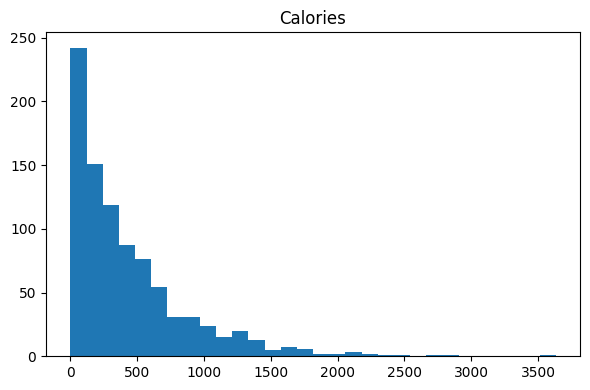

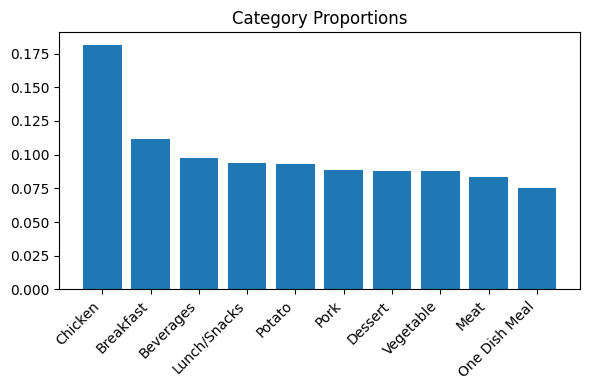

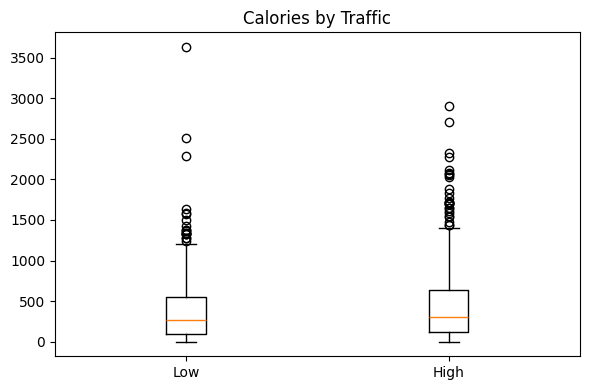

In [4]:

# Univariate: calories
v = pd.to_numeric(df["calories"], errors="coerce").dropna()
plt.figure(); plt.hist(v, bins=30); plt.title("Calories"); plt.tight_layout(); plt.show()

# Univariate: category proportions
counts = df["category"].value_counts(normalize=True)
plt.figure(); plt.bar(counts.index.astype(str), counts.values); plt.xticks(rotation=45, ha="right"); plt.title("Category Proportions"); plt.tight_layout(); plt.show()

# Multivariate: calories by traffic
d0 = df.loc[df["high_traffic"]==0, "calories"].dropna()
d1 = df.loc[df["high_traffic"]==1, "calories"].dropna()
plt.figure(); plt.boxplot([d0.values, d1.values], labels=["Low","High"]); plt.title("Calories by Traffic"); plt.tight_layout(); plt.show()


## 3) Feature Engineering (v5.1)

In [5]:

df_fe = df.copy()

# Log transforms
for c in ["calories","carbohydrate","sugar","protein"]:
    df_fe["log_"+c] = np.log1p(pd.to_numeric(df_fe[c], errors="coerce"))

# Ratios & densities
df_fe["calorie_density"] = df_fe["calories"] / (df_fe["servings"].replace(0, np.nan))
df_fe["sugar_to_protein_ratio"] = df_fe["sugar"] / (df_fe["protein"] + 1)
df_fe["carb_to_cal_ratio"] = df_fe["carbohydrate"] / (df_fe["calories"] + 1)

# Interactions + flags
df_fe["sugar_x_protein"] = df_fe["sugar"] * df_fe["protein"]
df_fe["carb_x_protein"] = df_fe["carbohydrate"] * df_fe["protein"]
df_fe["is_family_serving"] = (pd.to_numeric(df_fe["servings"], errors="coerce") >= 4).astype(int)

# Features
base_num = ["calories","carbohydrate","sugar","protein"]
log_num  = ["log_"+c for c in base_num]
new_feats = ["calorie_density","sugar_to_protein_ratio","carb_to_cal_ratio","sugar_x_protein","carb_x_protein","is_family_serving"]
cat_cols = ["category","servings"]

use_feats = [c for c in base_num + log_num + new_feats + cat_cols if c in df_fe.columns]

X = df_fe[use_feats].copy()
y = df_fe["high_traffic"].astype(int).values

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=777, stratify=y)

# Robust preprocessing
for col in ["category","servings"]:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str)
        X_valid[col] = X_valid[col].astype(str)

num_cols = [c for c in X_train.columns if c not in ["category","servings"] and pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols2 = [c for c in ["category","servings"] if c in X_train.columns]

num_t = Pipeline([("impute", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_t = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))])
prep = ColumnTransformer([("num", num_t, num_cols), ("cat", cat_t, cat_cols2)])

print("Numeric:", num_cols)
print("Categorical:", cat_cols2)


Numeric: ['calories', 'carbohydrate', 'sugar', 'protein', 'log_calories', 'log_carbohydrate', 'log_sugar', 'log_protein', 'calorie_density', 'sugar_to_protein_ratio', 'carb_to_cal_ratio', 'sugar_x_protein', 'carb_x_protein', 'is_family_serving']
Categorical: ['category', 'servings']


## 4) Strong Single Models (Accuracy-focused)

In [6]:

models = {
    "LR_bal":   Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5, solver="liblinear"))]),
    "LR_plain": Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000, class_weight=None,       C=1.5, solver="liblinear"))]),
    "RF_bal":   Pipeline([("prep", prep), ("clf", RandomForestClassifier(n_estimators=600, max_depth=14, min_samples_split=6,
                                                                         min_samples_leaf=2, n_jobs=-1, random_state=777, class_weight="balanced"))]),
    "RF_plain": Pipeline([("prep", prep), ("clf", RandomForestClassifier(n_estimators=700, max_depth=16, min_samples_split=8,
                                                                         min_samples_leaf=2, n_jobs=-1, random_state=777, class_weight=None))]),
    "HGB_fast": Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(max_depth=6, learning_rate=0.06, max_iter=600, random_state=777))]),
    "HGB_slow": Pipeline([("prep", prep), ("clf", HistGradientBoostingClassifier(max_depth=7, learning_rate=0.045, max_iter=800, random_state=777))]),
}

if XGB_OK:
    models["XGB_wide"] = Pipeline([
        ("prep", prep),
        ("clf", XGBClassifier(n_estimators=1200, max_depth=7, learning_rate=0.045,
                              subsample=0.8, colsample_bytree=0.85, reg_lambda=1.2,
                              eval_metric="auc", tree_method="hist", random_state=777, n_jobs=-1))
    ])
    print("XGBoost available — added XGB_wide.")
else:
    print("XGBoost not available — continuing without it.")

# Fit + threshold sweep
store = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_valid)[:, 1]
    thr, acc = best_accuracy_threshold(proba, y_valid, low=0.10, high=0.90, step=0.005)
    pred = (proba >= thr).astype(int)
    f1  = f1_score(y_valid, pred)
    auc = roc_auc_score(y_valid, proba)
    store[name] = {"proba": proba, "thr": thr, "acc": acc, "f1": f1, "auc": auc}
    print(f"{name} — Acc(best): {acc:.3f} @thr={thr:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")


XGBoost available — added XGB_wide.
LR_bal — Acc(best): 0.758 @thr=0.540 | F1: 0.793 | AUC: 0.813
LR_plain — Acc(best): 0.753 @thr=0.605 | F1: 0.800 | AUC: 0.812
RF_bal — Acc(best): 0.747 @thr=0.525 | F1: 0.793 | AUC: 0.810
RF_plain — Acc(best): 0.758 @thr=0.515 | F1: 0.808 | AUC: 0.800
HGB_fast — Acc(best): 0.732 @thr=0.100 | F1: 0.813 | AUC: 0.789
HGB_slow — Acc(best): 0.721 @thr=0.230 | F1: 0.789 | AUC: 0.780
XGB_wide — Acc(best): 0.737 @thr=0.610 | F1: 0.777 | AUC: 0.793


## 5) Ensemble (Weight Search) & 6) Final Evaluation + Business Metrics


FINAL (Ensemble(LR_bal,LR_plain,RF_bal,RF_plain,HGB_fast,HGB_slow,XGB_wide) weights=[0.07142857142857142, 0.14285714285714285, 0.2857142857142857, 0.21428571428571427, 0.07142857142857142, 0.07142857142857142, 0.14285714285714285]) — Acc:0.763 F1:0.810 AUC:0.814 thr:0.525

Confusion Matrix:
 [[49 26]
 [19 96]]

Classification Report:
               precision    recall  f1-score   support

           0      0.721     0.653     0.685        75
           1      0.787     0.835     0.810       115

    accuracy                          0.763       190
   macro avg      0.754     0.744     0.748       190
weighted avg      0.761     0.763     0.761       190

P@25: 0.960
P@50: 0.920
P@100: 0.790


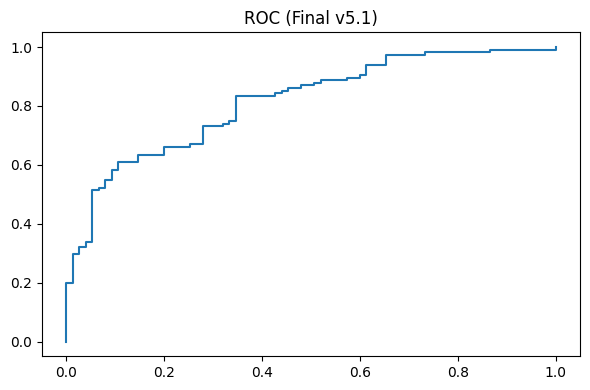

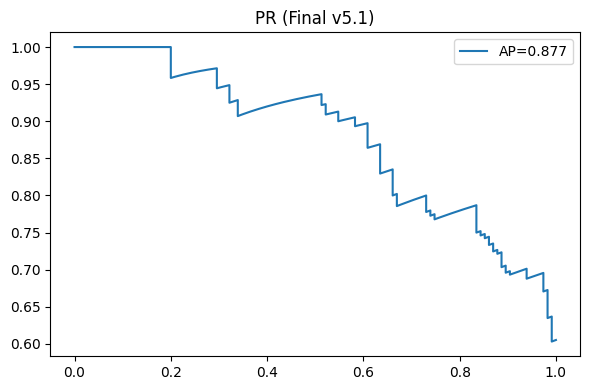

In [7]:

# Weight search to maximize accuracy
keys = list(store.keys())
probas = [store[k]["proba"] for k in keys]

def eval_weights(ws):
    w = np.array(ws, dtype=float); w = w / w.sum()
    blend = np.zeros_like(probas[0])
    for i, p in enumerate(probas): blend += w[i] * p
    thr, acc = best_accuracy_threshold(blend, y_valid, low=0.10, high=0.90, step=0.005)
    return acc, thr, w, blend

best_acc, best_thr, best_w, best_blend = -1.0, 0.5, None, None
for ws in itertools.product([1,2,3,4], repeat=len(keys)):
    acc, thr, w, blend = eval_weights(ws)
    if acc > best_acc:
        best_acc, best_thr, best_w, best_blend = acc, thr, w, blend

# Compare with best single
single_best = max(((k, v["acc"]) for k, v in store.items()), key=lambda x: x[1])
champ_name, champ_acc = single_best

if best_acc >= champ_acc:
    final_name = "Ensemble(" + ",".join(keys) + ") weights=" + str(best_w.tolist())
    final_proba = best_blend
    final_thr   = best_thr
else:
    final_name  = champ_name
    final_proba = store[champ_name]["proba"]
    final_thr   = store[champ_name]["thr"]

# Final report
final_pred = (final_proba >= final_thr).astype(int)
acc = accuracy_score(y_valid, final_pred)
f1  = f1_score(y_valid, final_pred)
auc = roc_auc_score(y_valid, final_proba)
print(f"\nFINAL ({final_name}) — Acc:{acc:.3f} F1:{f1:.3f} AUC:{auc:.3f} thr:{final_thr:.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_valid, final_pred))
print("\nClassification Report:\n", classification_report(y_valid, final_pred, digits=3))

for K in [25, 50, 100]:
    print(f"P@{K}: {precision_at_k(final_proba, y_valid, K):{'.3f'}}")

fpr, tpr, _ = roc_curve(y_valid, final_proba)
p, r, _ = precision_recall_curve(y_valid, final_proba)
ap = average_precision_score(y_valid, final_proba)
plt.figure(); plt.plot(fpr, tpr); plt.title("ROC (Final v5.1)"); plt.tight_layout(); plt.show()
plt.figure(); plt.plot(r, p, label=f"AP={ap:.3f}"); plt.legend(); plt.title("PR (Final v5.1)"); plt.tight_layout(); plt.show()


## 7) Final Summary & Recommendations

**Summary**
- Cleaned & validated dataset; robust categoricals.
- Richer features (log/ratios/densities/interactions); accuracy-first threshold sweeps.
- Strong single models + soft-vote ensemble with weight search; champion by **accuracy**.
- Report prints **Accuracy**, **F1**, **AUC**, **Precision@K**, plus ROC/PR curves.

**Recommendations**
1. Keep the accuracy-optimized threshold unless recall is critical.
2. If capacity-limited, use top-N ranking and **Precision@K** as KPI.
3. Consider probability calibration if thresholds are sensitive.
4. Re-run the ensemble weight search periodically; monitor drift.
